In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, orth, qr
from scipy.optimize import curve_fit
from numpy import sin, cos, pi
cmap = plt.cm.plasma
from scipy.ndimage import gaussian_filter1d
from scipy.signal import wiener
from scipy.signal import wiener, butter, freqs, convolve, freqz
from scipy.fft import fft, ifft, fftshift, ifftshift, fftfreq
from scipy.interpolate import (RegularGridInterpolator, RectBivariateSpline,
                               interpn, griddata, Rbf, interp1d, interp2d)
from scipy.interpolate._rgi_cython import evaluate_linear_2d, find_indices
from scipy.signal import convolve2d as conv2
from scipy.ndimage import gaussian_filter
import warnings
from smooth_POD_ROM.reduced_order_model import pulse, delta_n_width, train_ROM, L2_error, zielfunktion
from smooth_POD_ROM.pre_processing import convolve_f, gaussian_f, gaussian, smoothen
from smooth_POD_ROM.post_processing import get_sigma
from smooth_POD_ROM.post_processing import post_process as post_processOLD
from scipy.optimize import minimize
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [29]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 2.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
#plt.rcParams['font.serif'] = ['Times New Roman']
pth = "../Plots/"

markevery = 40

8.030570172000001


load snapshots
train = ss[::100]
dt = 0.001
nu = 0.002

In [30]:
pth = "//files.ad.ife.no/MatPro_files/Florian/Burgers1D/"
num_steps = 1501
dt = 0.001
nu = 0.001
sigma = 0.02
c = 2
num_iter1 = 10
num_iter2 = 20
clip = True
x = np.load(pth+"x.npy").ravel()
t = np.arange(0, 3, dt)[:num_steps]
dx = x[1]-x[0]
rank = min(len(x), len(t))
shape = x.shape

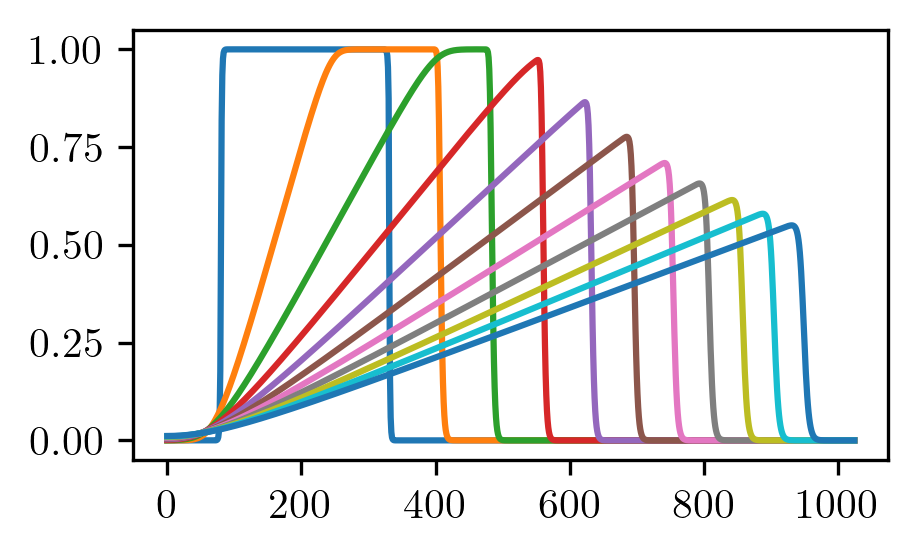

In [31]:
for i in np.arange(0, 1500+1, 150):
    ss = np.load(pth+"1fine_snapshot{:02d}.npy".format(i))
    plt.plot(ss)

In [5]:
X = np.zeros((len(x), num_steps))
for i, n in enumerate(range(0, num_steps, 5)):
    X[:, n] = np.load(pth+"1fine_snapshot{:02d}.npy".format(n))

Text(0, 0.5, '$x$')

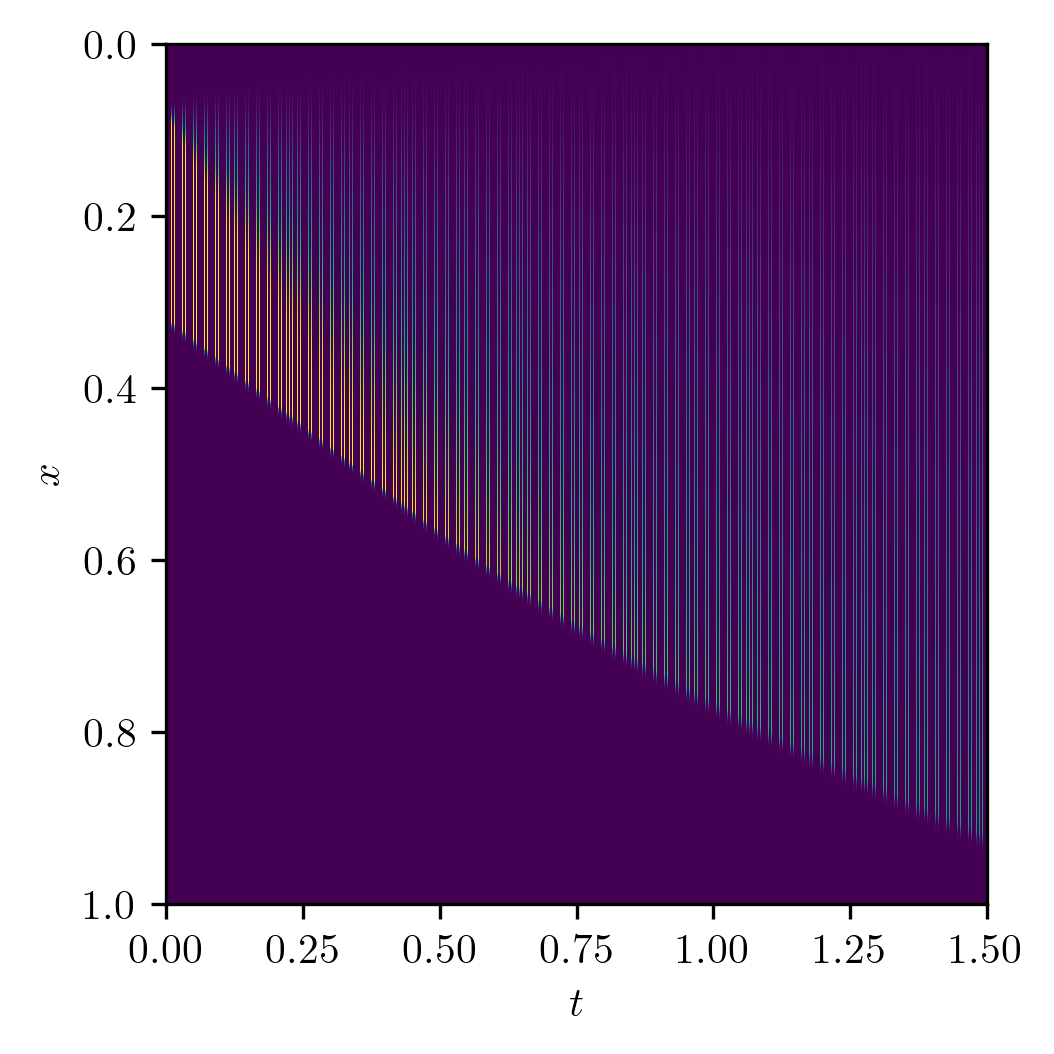

In [6]:
fig, ax = plt.subplots(figsize=(4.59/2.54 *2, 4.59/2.54 *2))
ax.imshow(X, interpolation="none", extent=(0, 1.5, 1, 0), aspect="auto")
ax.set_xlabel("$t$")
ax.set_ylabel("$x$")

In [32]:
mu_train = t[:, None][::150]
X_train = X[:, ::150]

mu_test = t[:, None][::15]
X_test = X[:, ::15]

mu_val = t[:, None]
X_val = X

X_train_s = smoothen(X_train, sigma/dx, x.shape, truncate=12)
X_test_s = smoothen(X_test, sigma/dx, x.shape, truncate=12)
X_val_s = smoothen(X_val, sigma/dx, x.shape, truncate=12)

C:\Users\florianma\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


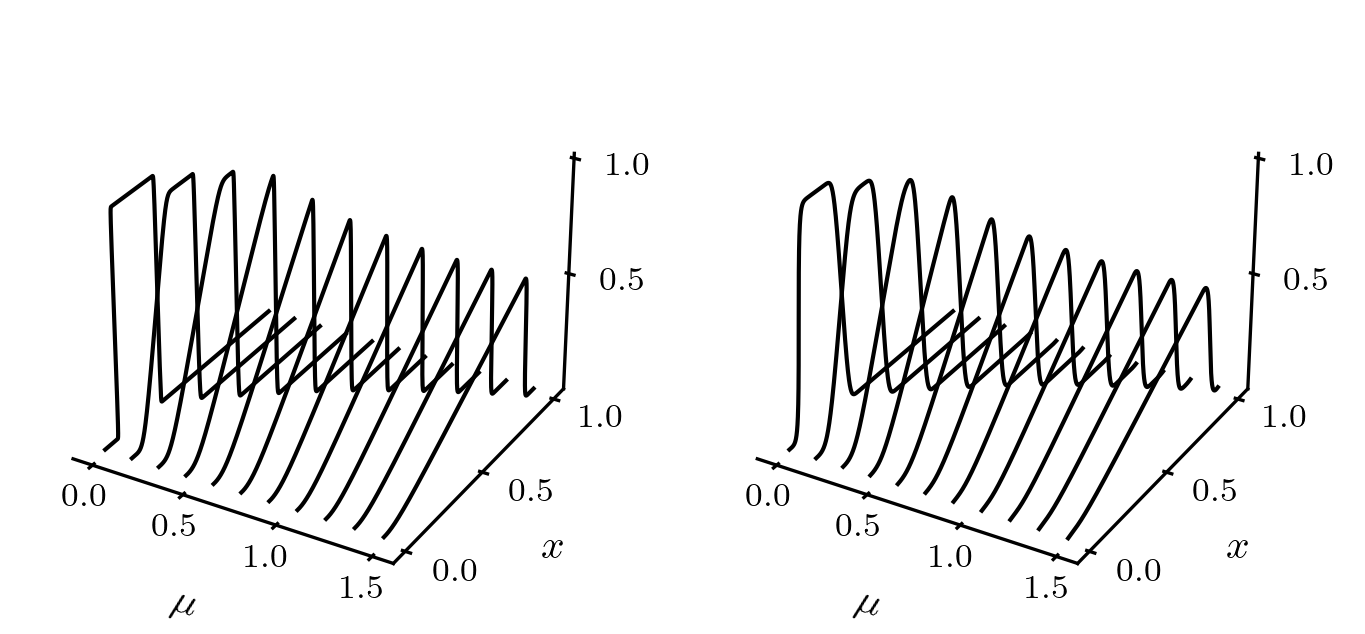

In [33]:
fig = plt.figure(figsize=(page_width_in, page_width_in/2), facecolor='white')
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

for i in range(len(mu_train)):
    ax1.plot(np.ones_like(x)*mu_train[i], x, X_train[:, i], "k-", lw=1)
    ax2.plot(np.ones_like(x)*mu_train[i], x, X_train_s[:, i], "k-", lw=1)
for ax in (ax1, ax2):
    ax.xaxis.labelpad = -5
    ax.yaxis.labelpad = -5
    xticks = [0.0,  0.2, 0.4, 0.6, 0.8]
    xticks = [0.0, 0.5, 1.0, 1.5]
    yticks = [0.0, 0.5, 1.0]
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.set_zticks([0.5, 1.0])
    ax.tick_params(axis='x', which='major', pad=-5)
    ax.tick_params(axis='y', which='major', pad=-2)
    ax.tick_params(axis='z', which='major', pad=0)
    ax.set_yticklabels(yticks, va='baseline', ha='left')
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        for tick in axis.get_major_ticks():
            tick.label1.set_fontsize(8)  # for some reasons it does not match
        axis.pane.set_edgecolor('white')

    ax.grid(False)
    ax.set_facecolor('white')
    ax.xaxis.pane.fill = False  # Remove the background pane
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.set_xlabel("$\mu$")
    ax.set_ylabel("$x$")
plt.show()


In [34]:
standard_rom = train_ROM(mu_train, X_train, rank=rank)
X_test_ROM = standard_rom.predict(mu_test).T
X_val_ROM = standard_rom.predict(mu_val).T

X_train_s = smoothen(X_train, sigma/dx, x.shape)
smooth_rom = train_ROM(mu_train, X_train_s, rank=rank)
X_test_sROM = smooth_rom.predict(mu_test).T
X_val_sROM = smooth_rom.predict(mu_val).T

In [35]:
X_test_sROMsOLD = post_processOLD(x, X_test_sROM, sigma, c, mu_test, mu_train, num_iter1,
                            x.shape, clip=True, progress=False)
X_test_sROMs2OLD = post_processOLD(x, X_test_sROM, sigma, c, mu_test, mu_train, num_iter2,
                            x.shape, clip=True, progress=False)

\\files.ad.ife.no\MatPro_files\Florian\Repositoties\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:24: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


20 [0.3]


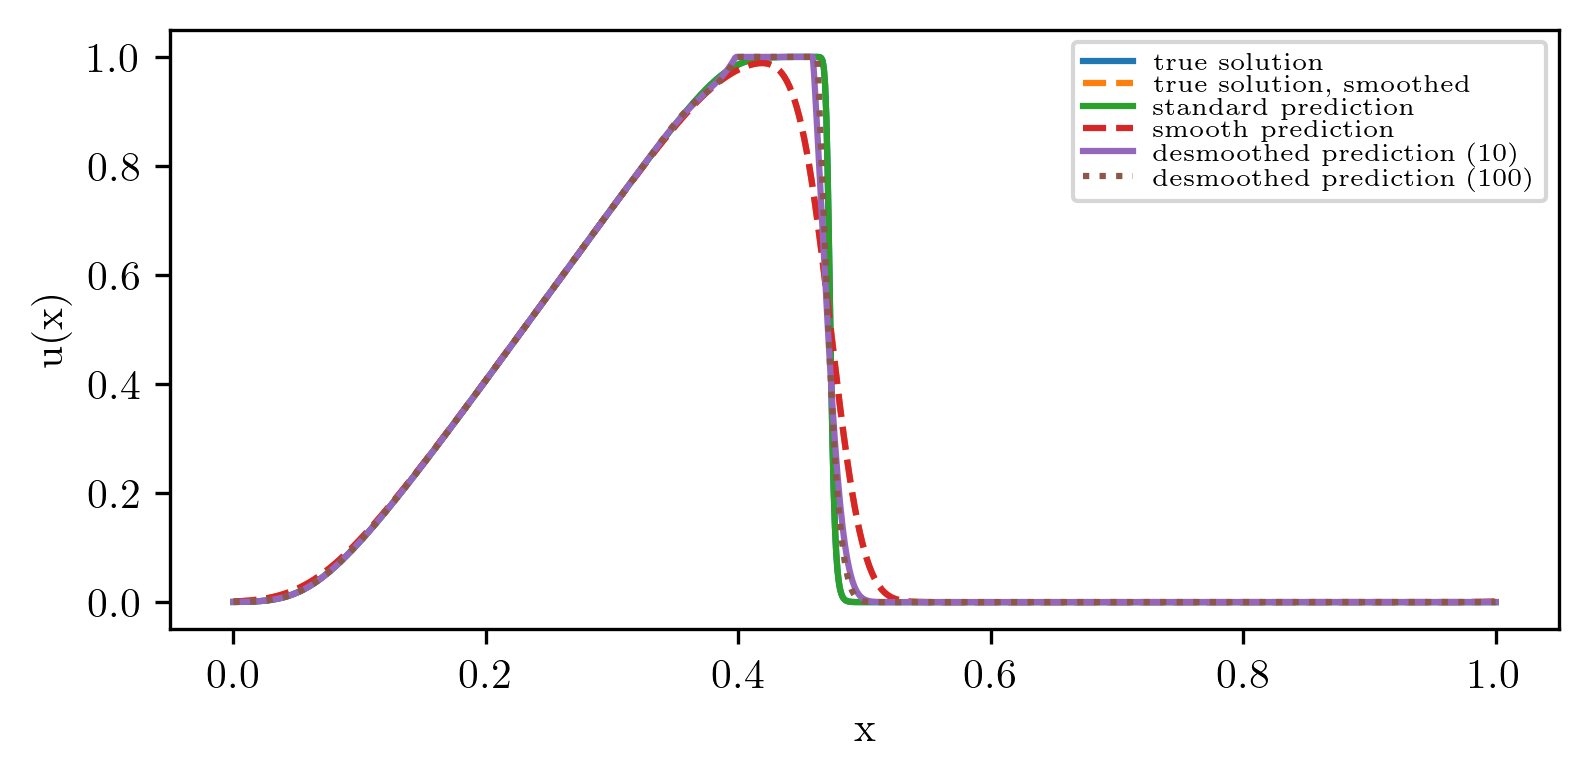

21 [0.315]


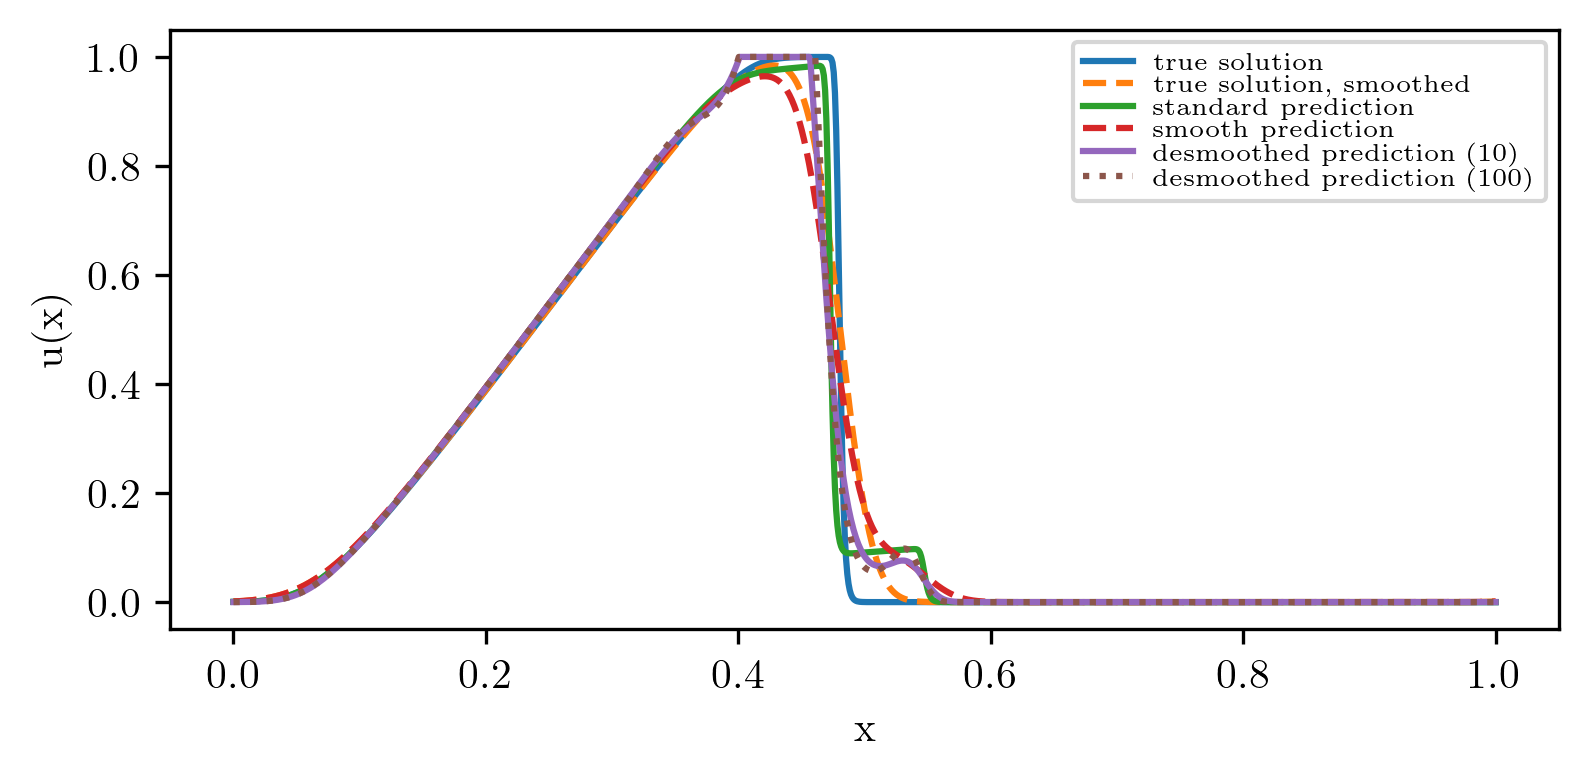

27 [0.405]


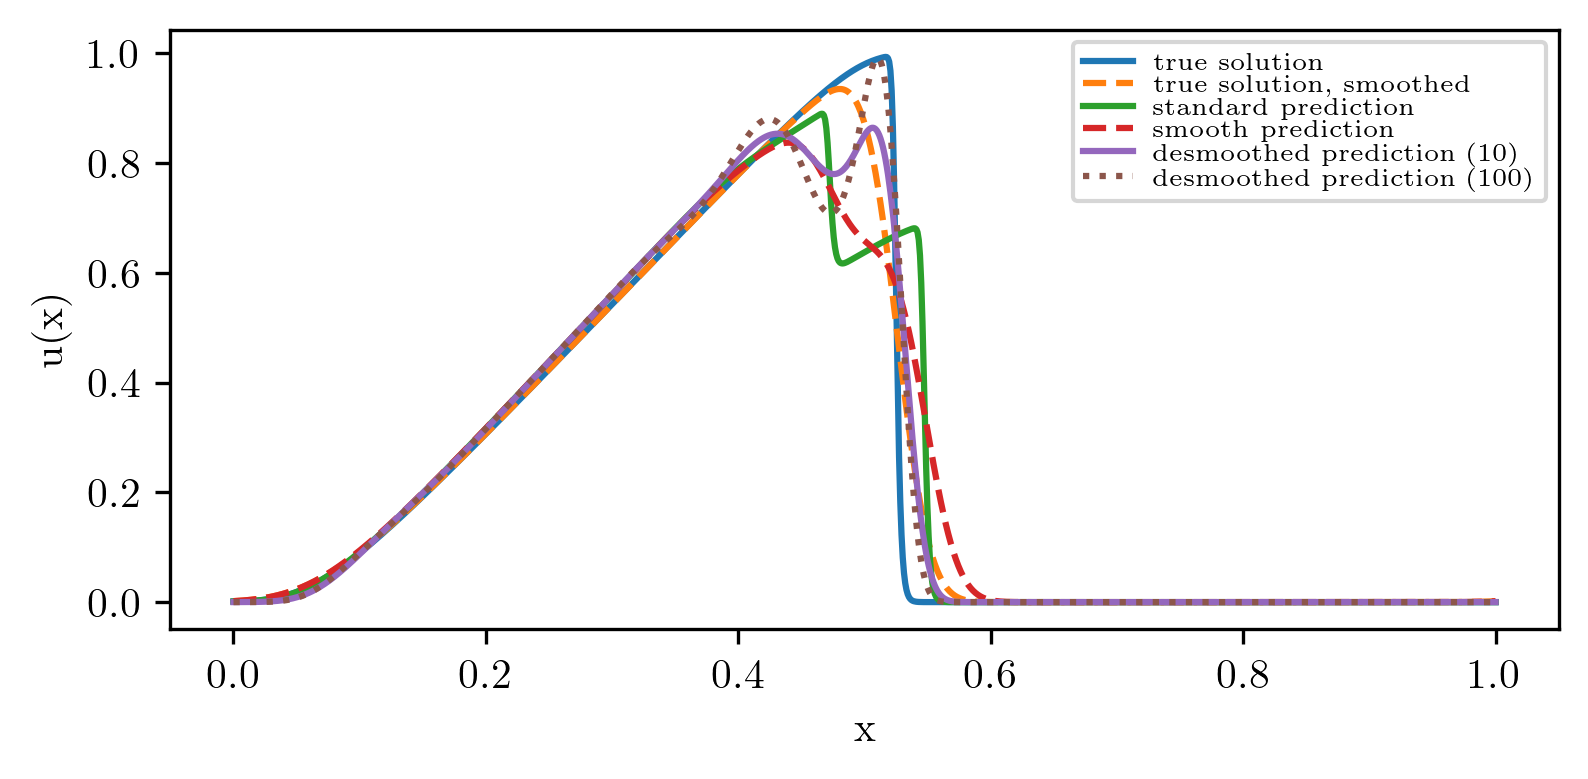

75 [1.125]


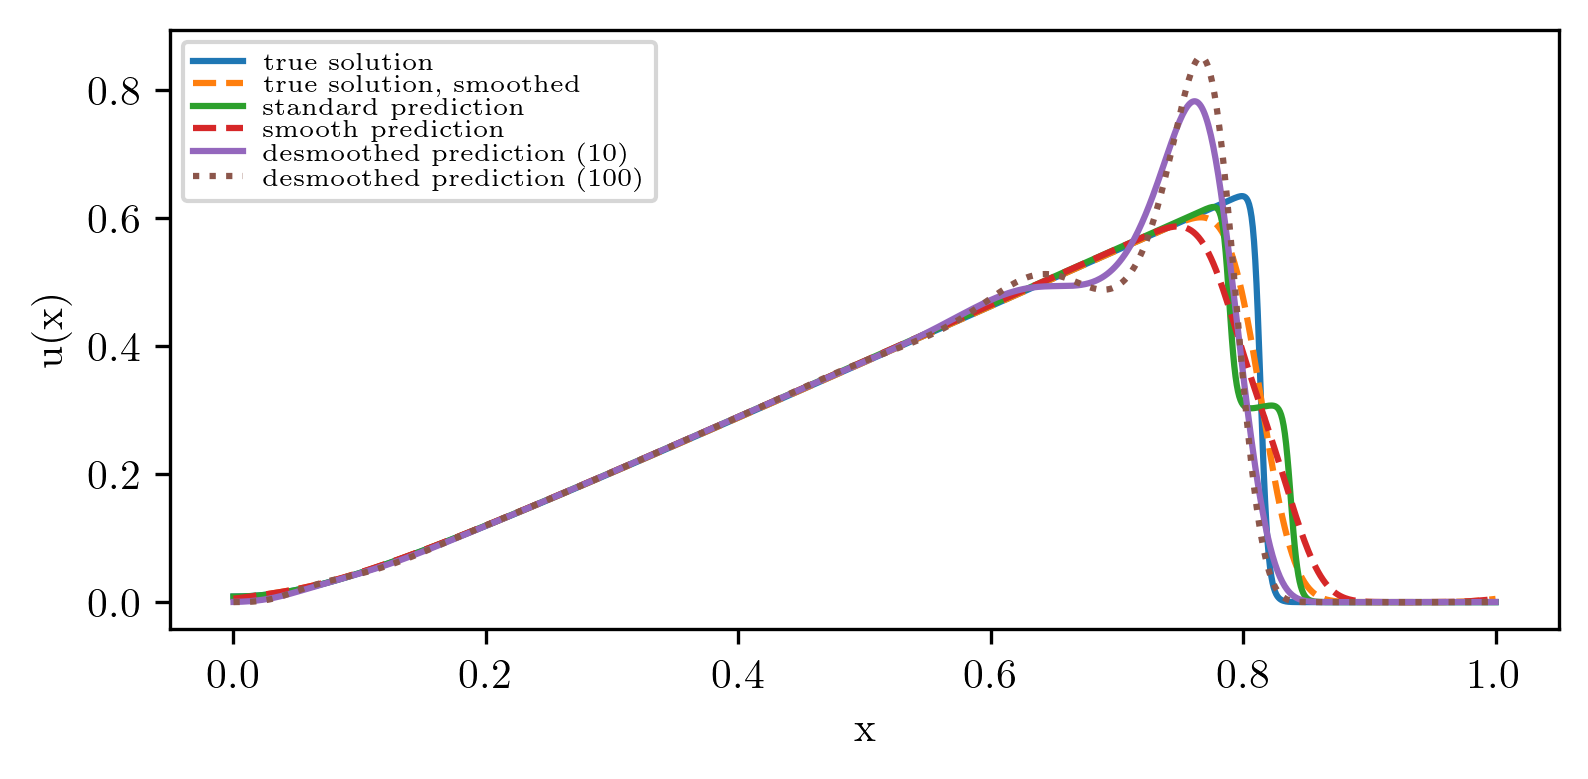

In [36]:
for i in [20, 21, 27, 75]:
    print(i, mu_test[i])
    plt.figure(figsize=(page_width_in, page_width_in/2))
    plt.plot(x, X_test[:, i], label="true solution")
    plt.plot(x, X_test_s[:, i], label="true solution, smoothed", ls="--")
    plt.plot(x, X_test_ROM[:, i], label="standard prediction")
    plt.plot(x, X_test_sROM[:, i], label="smooth prediction", ls="--")
    plt.plot(x, X_test_sROMsOLD[:, i], label="desmoothed prediction (10)")
    plt.plot(x, X_test_sROMs2OLD[:, i], label="desmoothed prediction (100)", ls=":")
    #mina, maxa = get_bounds(X_test_sROM[:, i])
#     plt.plot(x, minvals[:, i], "k--")
#     plt.plot(x, maxvals[:, i], "k--")
    plt.legend()
    plt.xlabel("x")
    plt.ylabel("u(x)")
    plt.show()

In [38]:
def get_bound(a, b, w=.1, m=0.0):
    # w: how far does a need to travel to match b? in % of the domain
    # rough estimation: w = 1/n_snapshots
    # we don't know anything about the direction of travel.
    # OR: we assume it goes to the right
    shape = a.shape
    a = np.atleast_2d(a)
    b = np.atleast_2d(b)
    # w: window width in percent
    mina = np.zeros_like(a)
    maxa = np.zeros_like(a)
    w1 = int(a.shape[0]*w)
    w2 = int(a.shape[1]*w)
    for i in range(a.shape[0]):
        for j in range(a.shape[1]):
#             ri = np.arange(i-w1, i+w1+1) % a.shape[0]
#             ci = np.arange(j-w2, j+w2+1) % a.shape[1]
            ri = np.arange(i-w1, i+1) % a.shape[0]
            ci = np.arange(j-w2, j+1) % a.shape[1]
            min_left, max_left = np.min(a[ri, :][:, ci]), np.max(a[ri, :][:, ci])
            ri = np.arange(i, i+w1+1) % a.shape[0]
            ci = np.arange(j, j+w2+1) % a.shape[1]
            min_right, max_right = np.min(b[ri, :][:, ci]), np.max(b[ri, :][:, ci])
            mina[i, j] = min(min_left, min_right)
            maxa[i, j] = max(max_left, max_right)
    mina.shape = maxa.shape = a.shape = b.shape = shape
    mina *= (1-m)
    maxa *= (1+m)
    return mina, maxa


def get_bounds(mu_train, mu_test, X_train):
    nx = len(X_train)
    n_ss_tst = len(mu_test)
    grid = (mu_train[:, 0].copy(), )
    indices_l, norm_distances_l = find_indices(grid, mu_test.T)

    minval = np.empty((nx, n_ss_tst))
    maxval = np.empty((nx, n_ss_tst))
    distances = np.empty((n_ss_tst))
    for i in range(len(mu_test)):
        dim = 0  # parameter dimension
        i_nn_left = indices_l[dim, i]
        norm_dist_left = norm_distances_l[dim, i]

        ss_l = X_train[:, i_nn_left]
        ss_r = X_train[:, i_nn_left+1]
        minval[:, i], maxval[:, i] = get_bound(ss_l, ss_r)

        distances[i] = min(norm_dist_left, 1-norm_dist_left)
    return minval, maxval, distances

def get_bounds(mu_train, mu_test, X_train):
    grid = (mu_train[:, 0].copy(), )
    indices_l, norm_distances_l = find_indices(grid, mu_test.T)


In [39]:

# for i in [20, 21, 27, 75]:
#     plt.figure()
#     plt.plot(x, X_test_sROM[:, i], "C0-")
#     plt.plot(x, X_test_ROM[:, i], "C1-")
#     plt.plot(x, X_test[:, i], "g-")
#     plt.plot(x, minvals[:, i], "k--")
#     plt.plot(x, maxvals[:, i], "k--")
#     plt.show()

In [40]:
def richardson_lucy(x, im_blur, sgm, num_iter=50, truth=None, damping=2,
                    mode="wrap", vmin=None, vmax=None):
    if not len(im_blur.shape) == 2:
        warnings.warn("image needs to be 2D")
    dx = x[1]-x[0]
    # TODO:
    truncate = 8
    if sgm/dx > 800:
        truncate = 1
    elif sgm/dx > 400:
        truncate = 2
    elif sgm/dx > 200:
        truncate = 3
    elif sgm/dx > 100:
        truncate = 4
    elif sgm/dx > 50:
        truncate = 5
    elif sgm/dx > 25:
        truncate = 5
    im_deconv = im_blur.copy()
    eps = 1e-12  # regularization to avoid 0 division
    #minval, maxval = get_bounds(im_blur)
    for _ in range(num_iter):
        #blurred = convolve2d(im_deconv.copy(), psf, boundary='symm', mode='same') + eps
        #blurred = convolve_f2D(im_deconv, psf_f2D) + eps
        blurred = gaussian_filter(
            im_deconv, sigma=sgm/dx, truncate=truncate, mode=mode)  # + eps
        blurred[np.abs(blurred) < eps] = eps
        relative_blur = im_blur / blurred
        #im_deconv *= convolve2d(relative_blur, psf_mirror, boundary='symm', mode='same')
        #im_deconv *= convolve_f2D(relative_blur, psf_f2D)
        error_estimate = gaussian_filter(
            relative_blur, sigma=sgm/dx, truncate=truncate, mode=mode)
        if damping:
            error_estimate[error_estimate > (1+damping)] = 1+damping
            error_estimate[error_estimate < (1-damping)] = 1-damping
        im_deconv *= error_estimate
        # clipping:
        too_small = im_deconv < vmin
        too_large = im_deconv > vmax
        im_deconv[too_small] = vmin[too_small]
        im_deconv[too_large] = vmax[too_large]
        if isinstance(truth, np.ndarray):
            print(_, np.mean((truth-im_deconv.ravel())**2)**.5)
    return im_deconv

def post_process(x, data, sigma, c, mu_test, mu_train, num_iter,
                 shape, X_train, progress=False):
    
    # from datetime import datetime
    minvals, maxvals, distances = get_bounds(mu_train, mu_test, X_train)
    sgm_est = sigma*(1 + c * distances)
    
    deconvolved = np.empty_like(data)
    for j in range(len(mu_test)):
        
        # t1 = datetime.now()
        deconvolved[:, j] = richardson_lucy(x, data[:, j].reshape(shape),
                                            sgm_est[j], num_iter, truth=None,
                                            vmin=minvals[:, j], vmax=maxvals[:, j]).ravel()
        # print("sgm=", sgm_est*1000, (datetime.now()-t1).total_seconds())
        if progress:
            print(j, end=", ")
    return deconvolved

In [41]:
X_test_sROMs = post_process(x, X_test_sROM, sigma, c, mu_test, mu_train, num_iter1,
                            x.shape, X_train=X_train, progress=False)
X_test_sROMs2 = post_process(x, X_test_sROM, sigma, c, mu_test, mu_train, num_iter2,
                            x.shape, X_train=X_train, progress=False)

C:\Users\florianma\AppData\Local\Temp\ipykernel_39768\3100943040.py:4: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


20 [0.3]


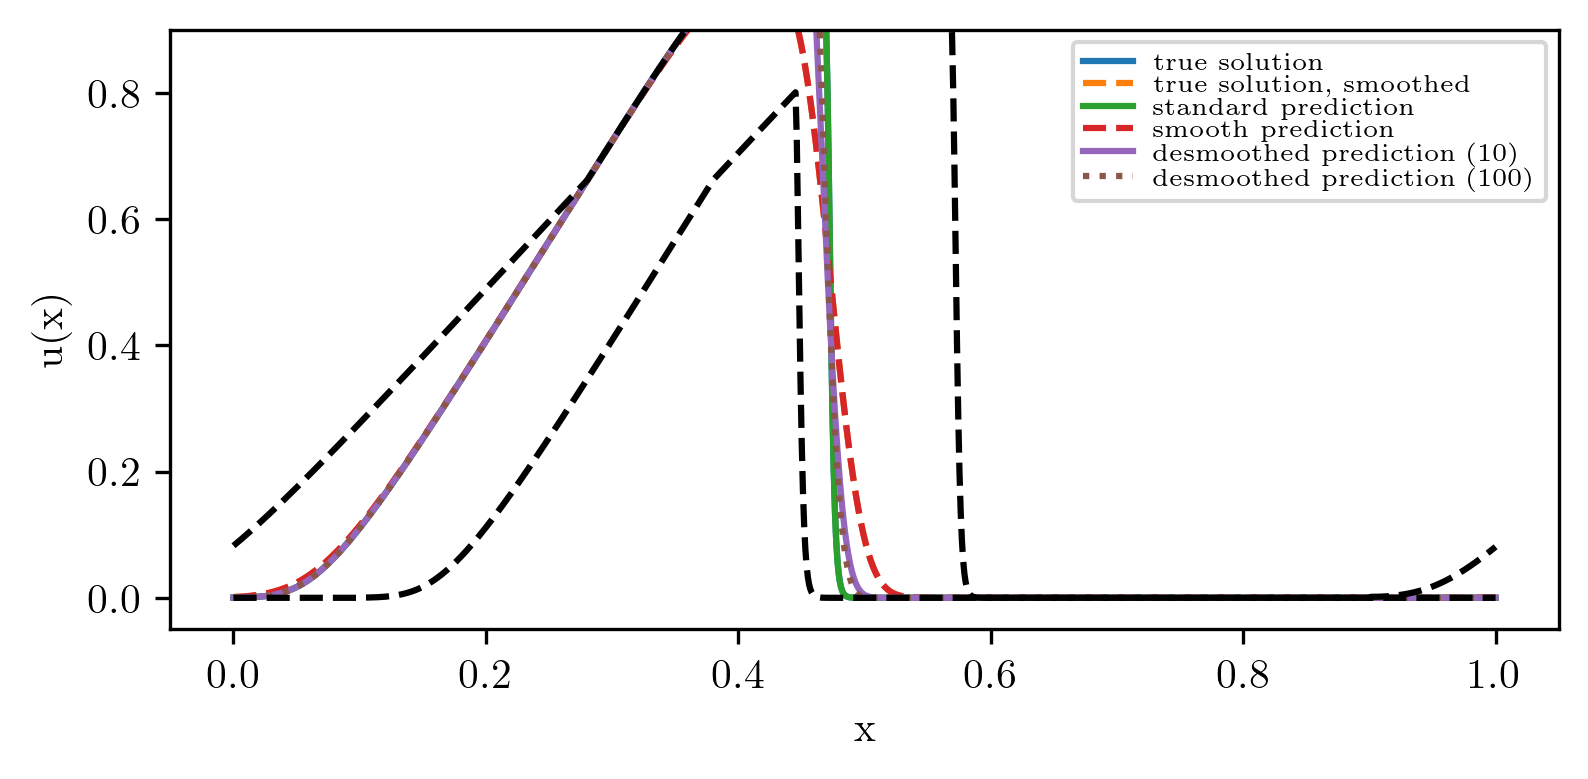

21 [0.315]


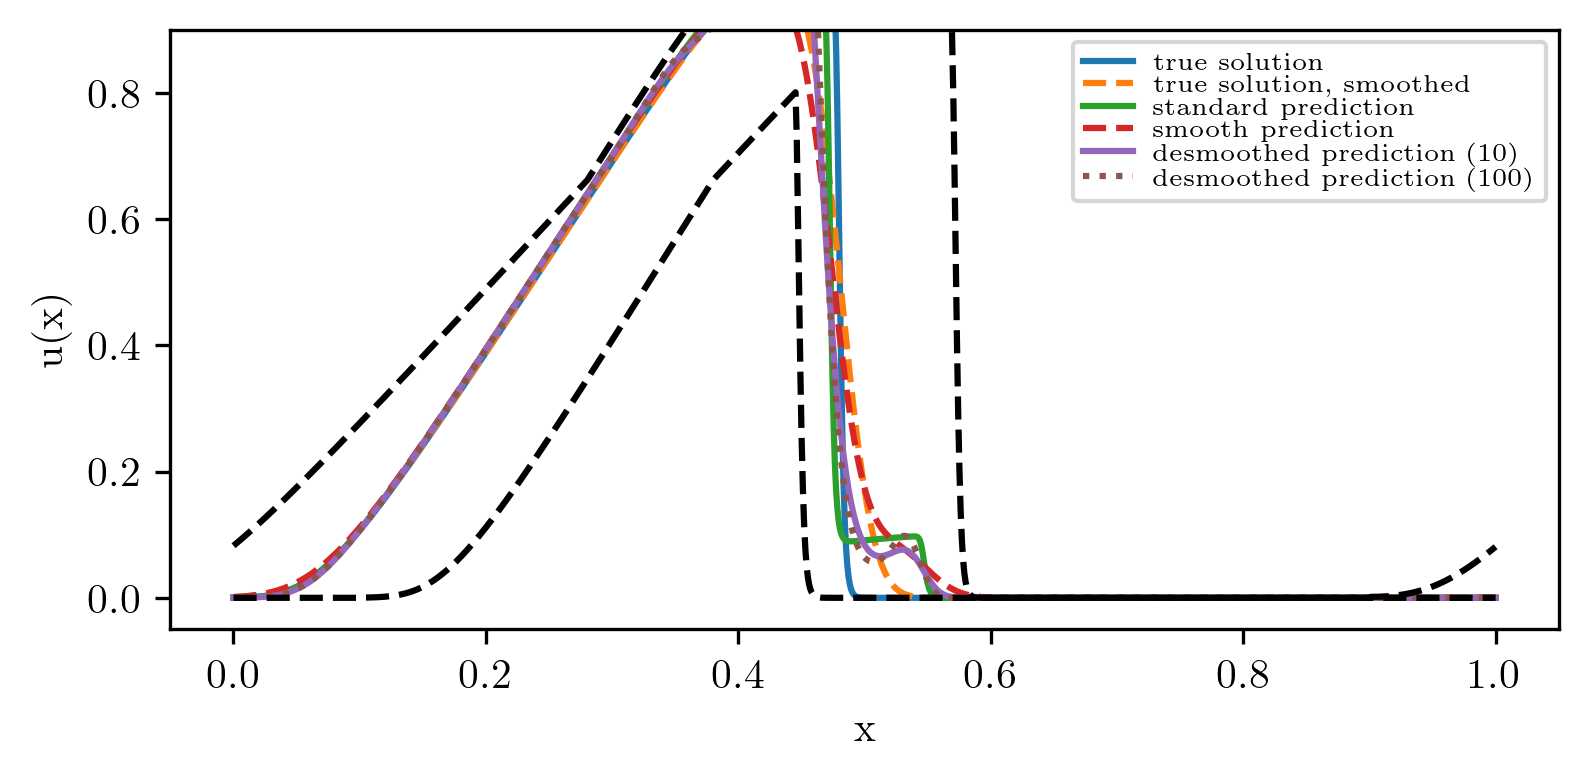

27 [0.405]


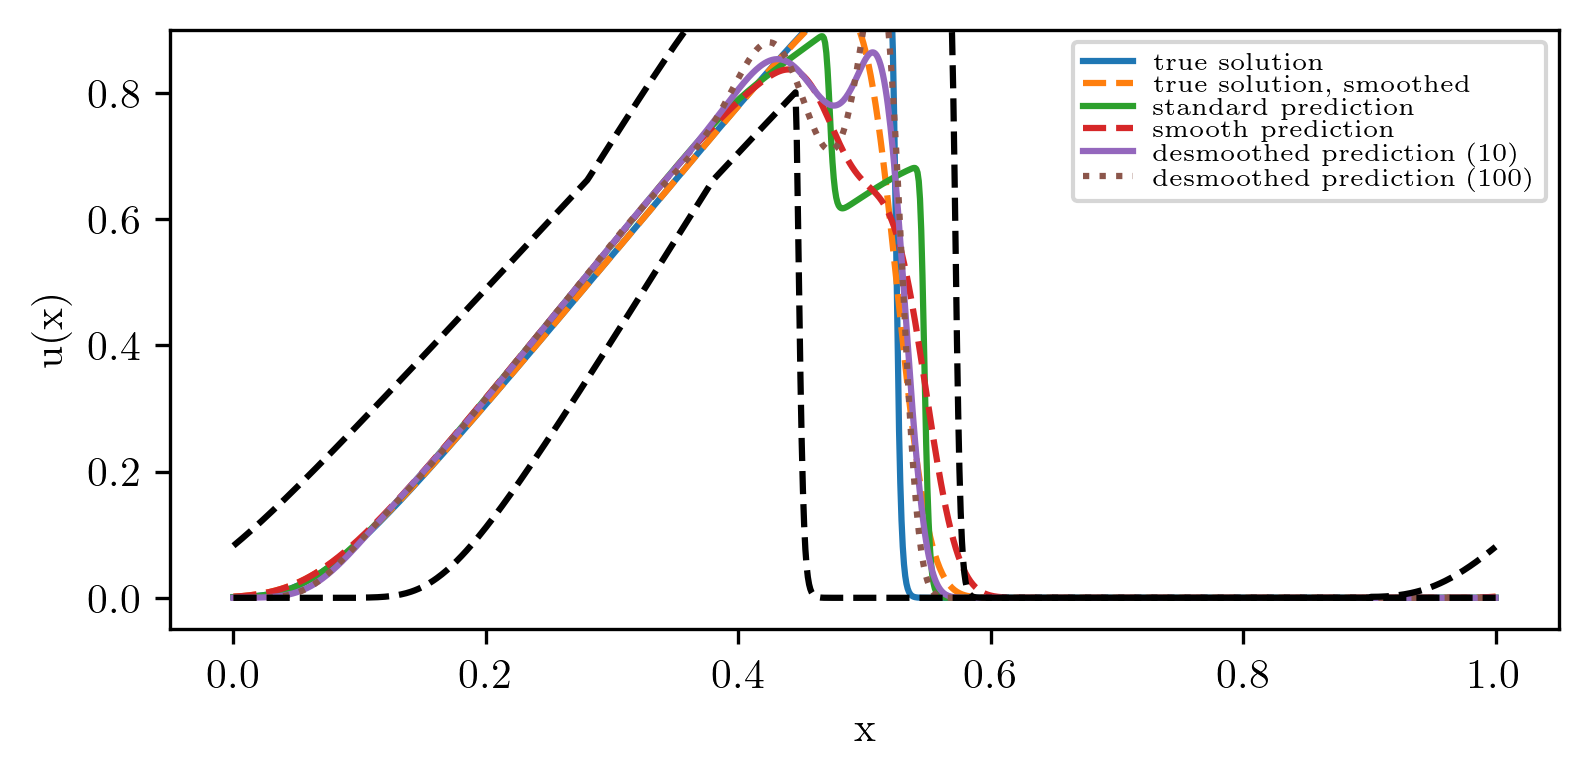

75 [1.125]


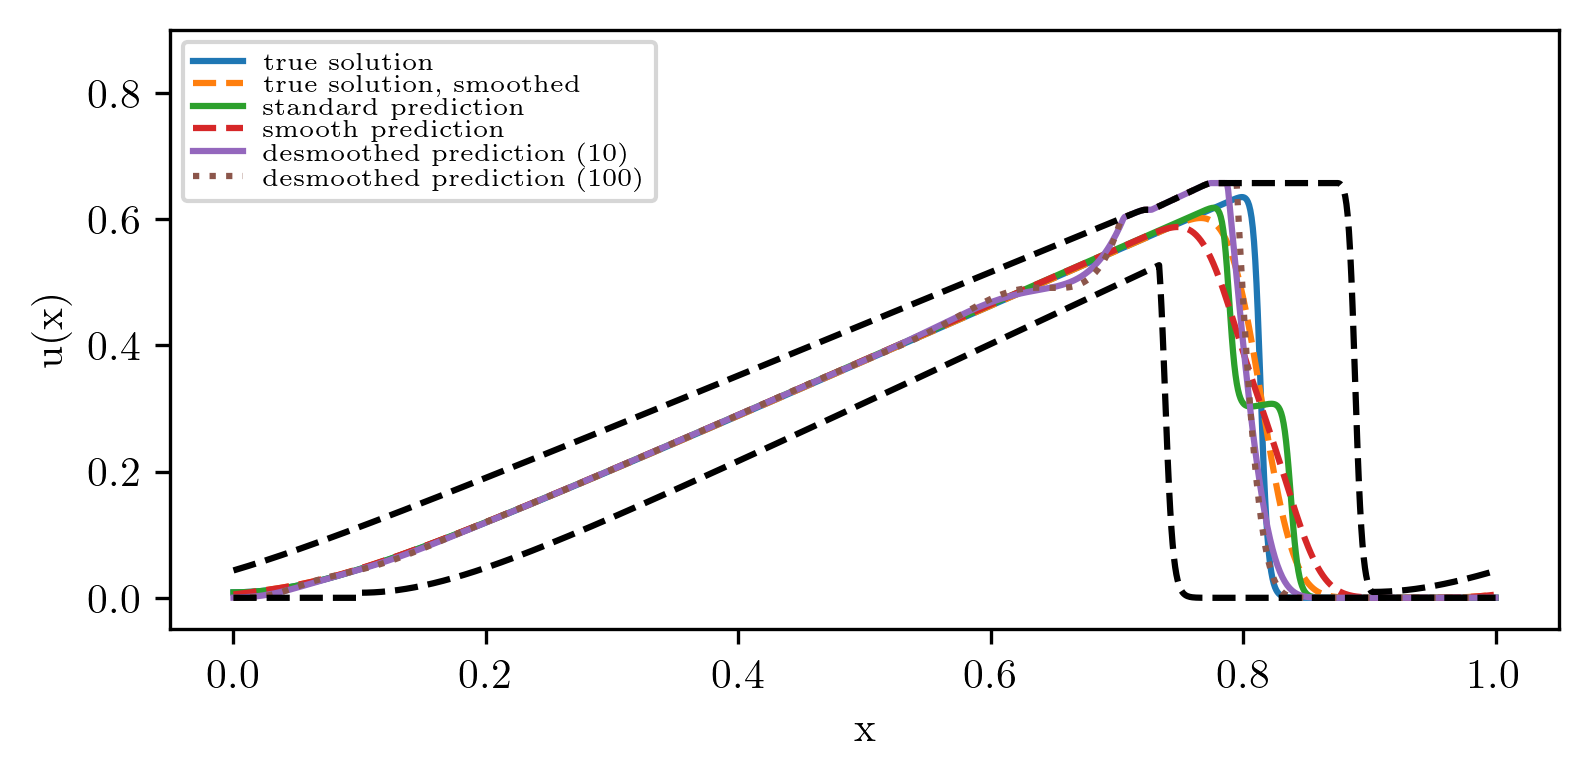

In [45]:
minvals, maxvals, distances = get_bounds(mu_train, mu_test, X_train)
for i in [20, 21, 27, 75]:
    print(i, mu_test[i])
    plt.figure(figsize=(page_width_in, page_width_in/2))
    plt.plot(x, X_test[:, i], label="true solution")
    plt.plot(x, X_test_s[:, i], label="true solution, smoothed", ls="--")
    plt.plot(x, X_test_ROM[:, i], label="standard prediction")
    plt.plot(x, X_test_sROM[:, i], label="smooth prediction", ls="--")
    plt.plot(x, X_test_sROMs[:, i], label="desmoothed prediction (10)")
    plt.plot(x, X_test_sROMs2[:, i], label="desmoothed prediction (100)", ls=":")
    #mina, maxa = get_bounds(X_test_sROM[:, i])
    plt.plot(x, minvals[:, i], "k--")
    plt.plot(x, maxvals[:, i], "k--")
    plt.ylim(-0.05, 0.9)
    plt.legend()
    plt.xlabel("x")
    plt.ylabel("u(x)")
    plt.show()

(101,)
1.0110238454664433
0.7165702790139972
0.6843947218235115


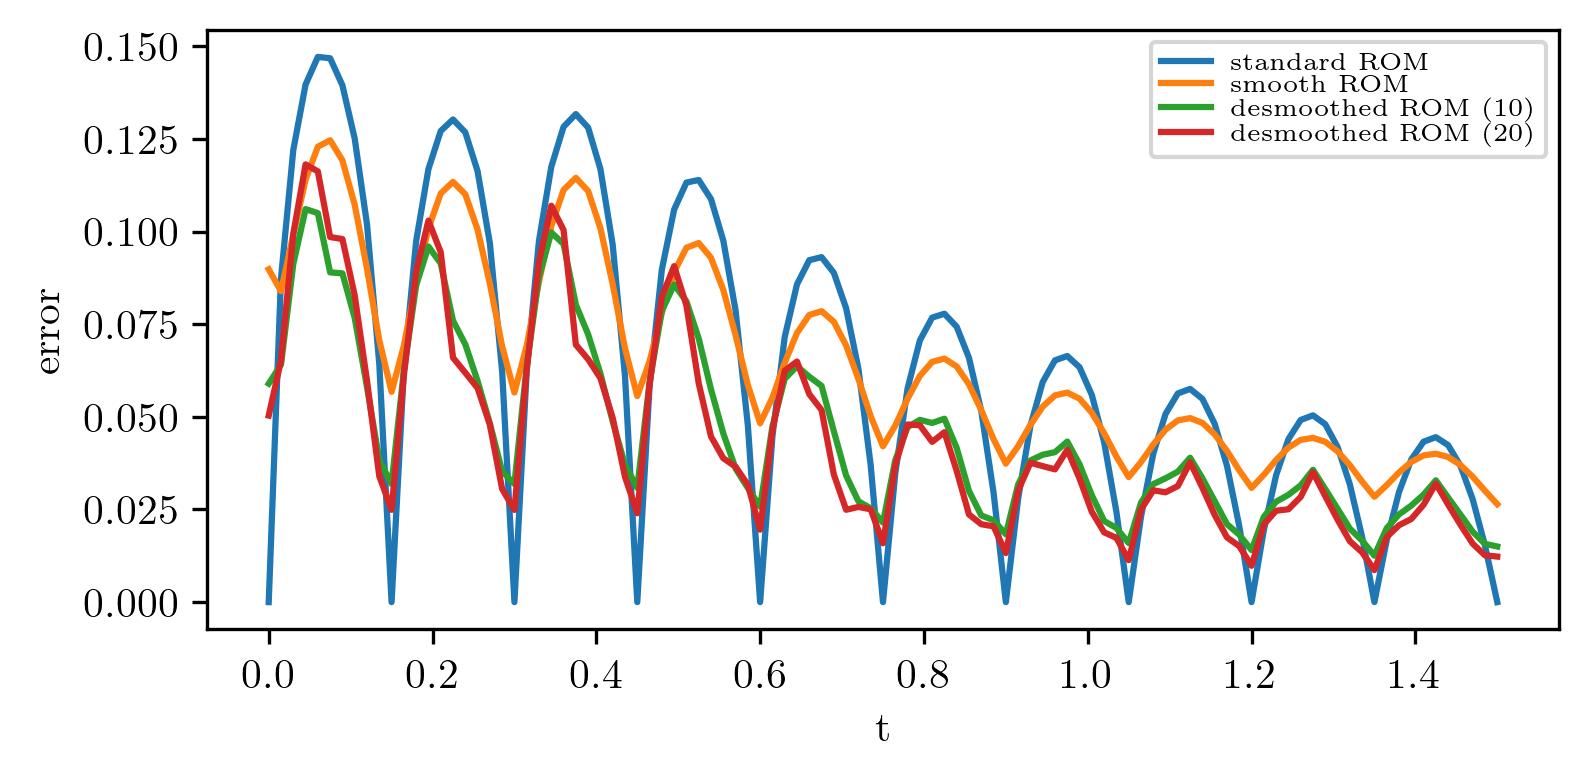

In [43]:
eROM = L2_error(X_test_ROM, X_test)
esROM = L2_error(X_test_sROM, X_test)
esROMs = L2_error(X_test_sROMs, X_test)
esROMs2 = L2_error(X_test_sROMs2, X_test)
print(eROM.shape)
plt.figure(figsize=(page_width_in, page_width_in/2))
plt.plot(mu_test, eROM, label="standard ROM")
plt.plot(mu_test, esROM, label="smooth ROM")
plt.plot(mu_test, esROMs, label="desmoothed ROM (10)")
plt.plot(mu_test, esROMs2, label="desmoothed ROM (20)")
plt.legend()
plt.xlabel("t")
plt.ylabel("error")

print(np.mean(esROM)/np.mean(eROM))
print(np.mean(esROMs)/np.mean(eROM))
print(np.mean(esROMs2)/np.mean(eROM))


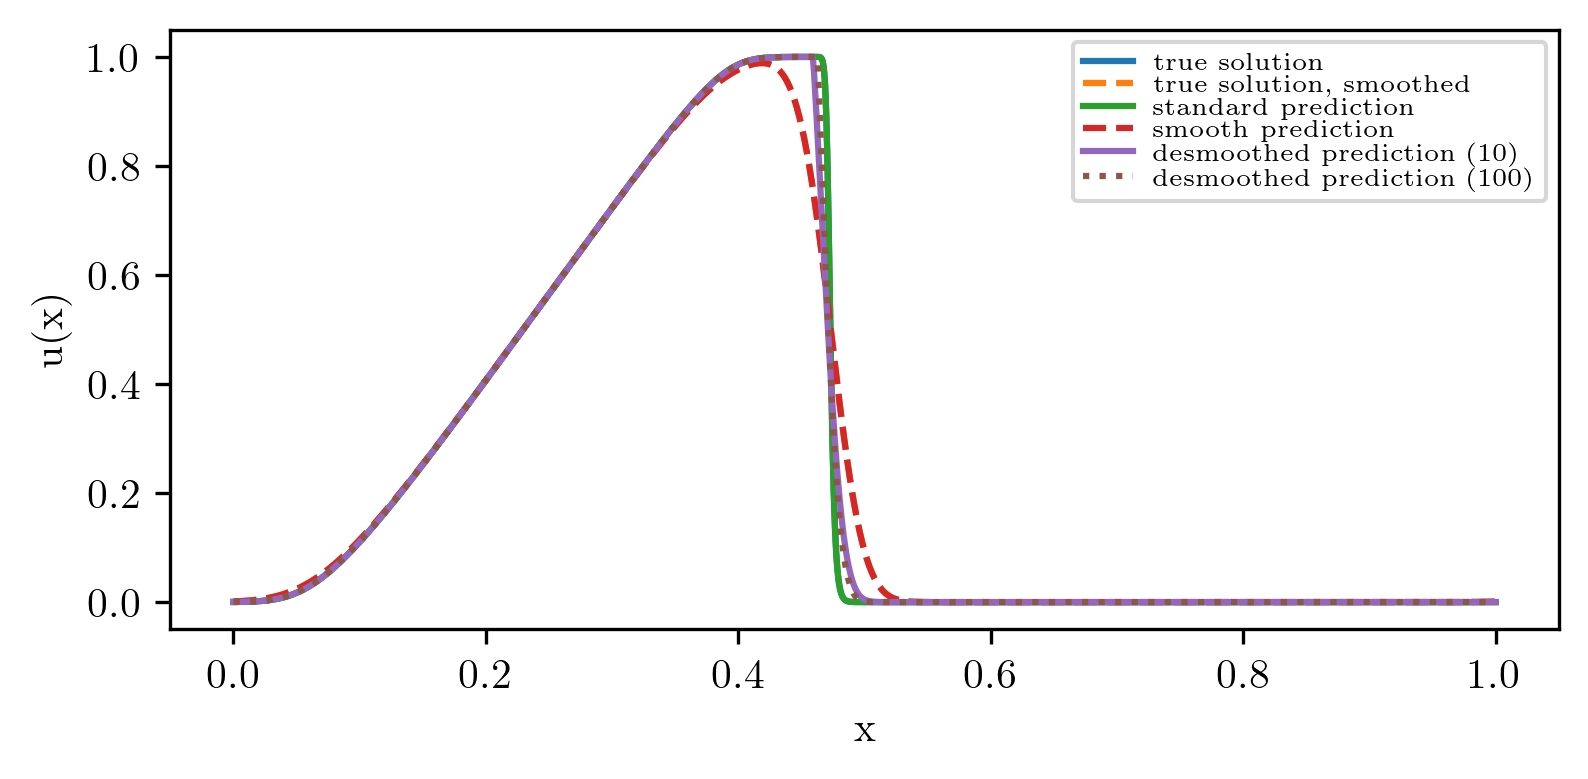

[0.02  0.024 0.028 0.032 0.036 0.04  0.036 0.032 0.028 0.024 0.02  0.024
 0.028 0.032 0.036 0.04  0.036 0.032 0.028 0.024 0.02  0.024 0.028 0.032
 0.036 0.04  0.036 0.032 0.028 0.024 0.02  0.024 0.028 0.032 0.036 0.04
 0.036 0.032 0.028 0.024 0.02  0.024 0.028 0.032 0.036 0.04  0.036 0.032
 0.028 0.024 0.02  0.024 0.028 0.032 0.036 0.04  0.036 0.032 0.028 0.024
 0.02  0.024 0.028 0.032 0.036 0.04  0.036 0.032 0.028 0.024 0.02  0.024
 0.028 0.032 0.036 0.04  0.036 0.032 0.028 0.024 0.02  0.024 0.028 0.032
 0.036 0.04  0.036 0.032 0.028 0.024 0.02  0.024 0.028 0.032 0.036 0.04
 0.036 0.032 0.028 0.024 0.02 ]
5
10
15
20
30


C:\Users\florianma\AppData\Local\Temp\ipykernel_39768\3100943040.py:4: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


50
100


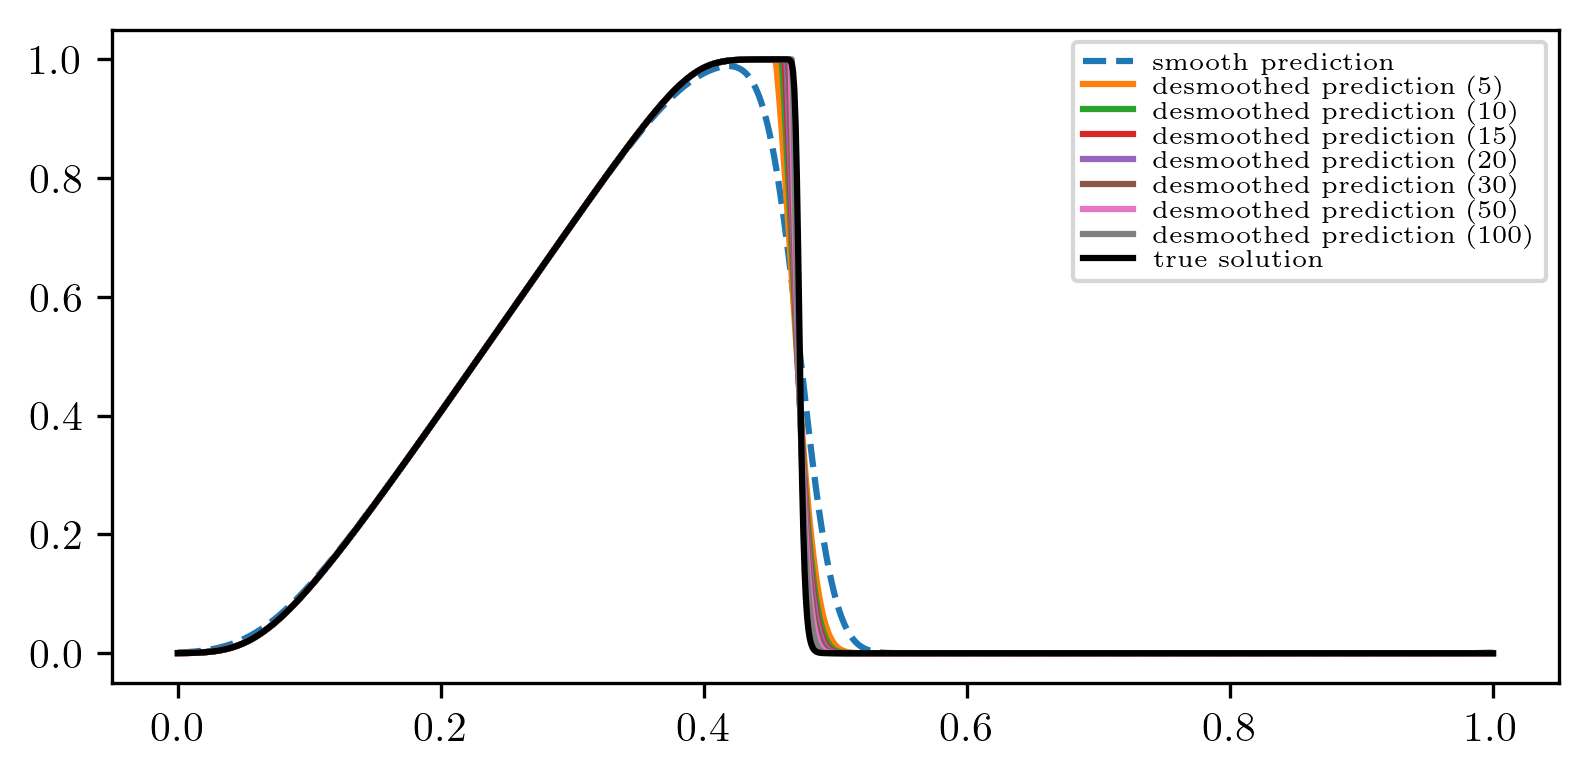

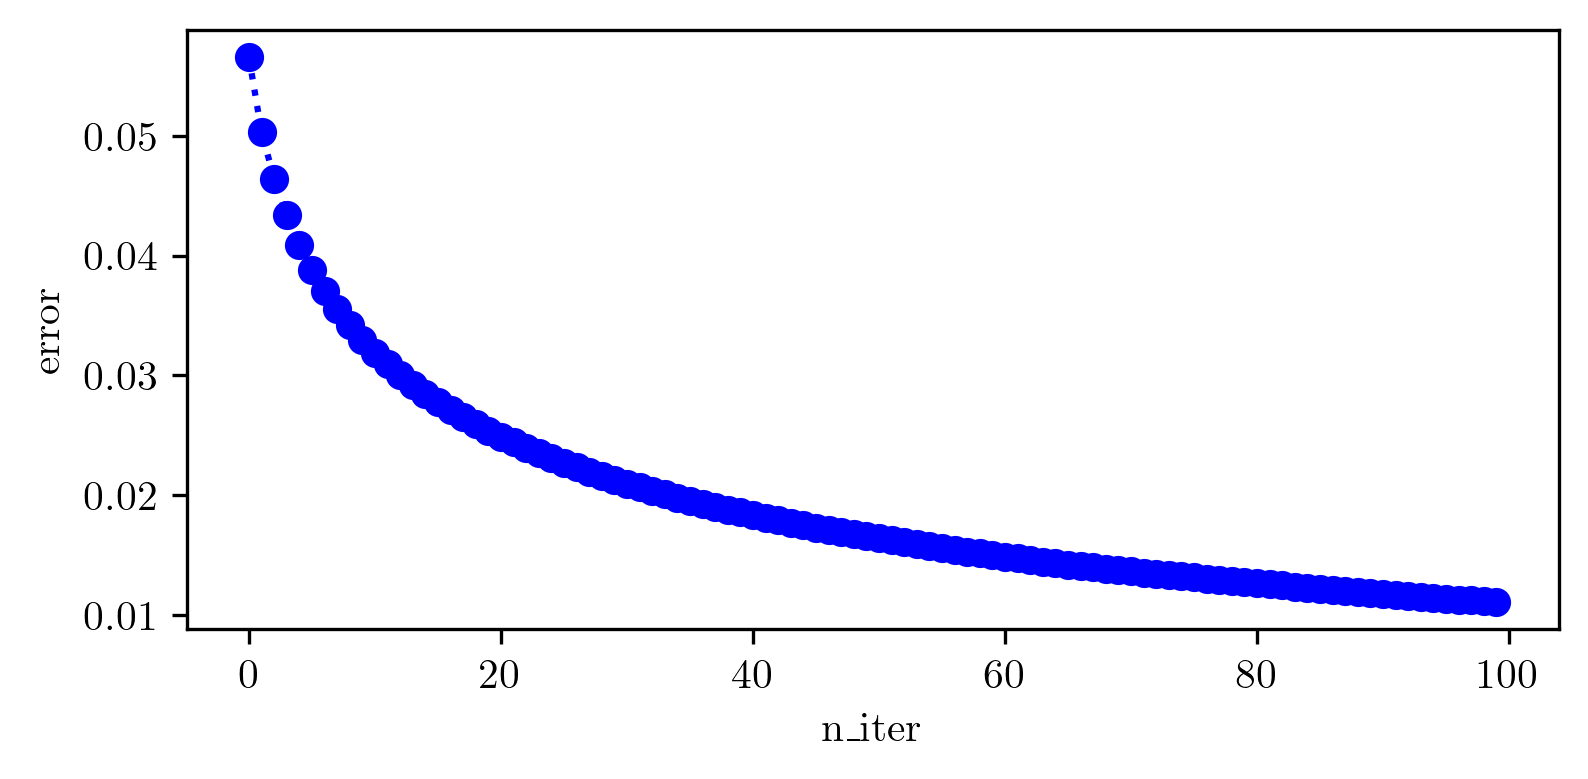

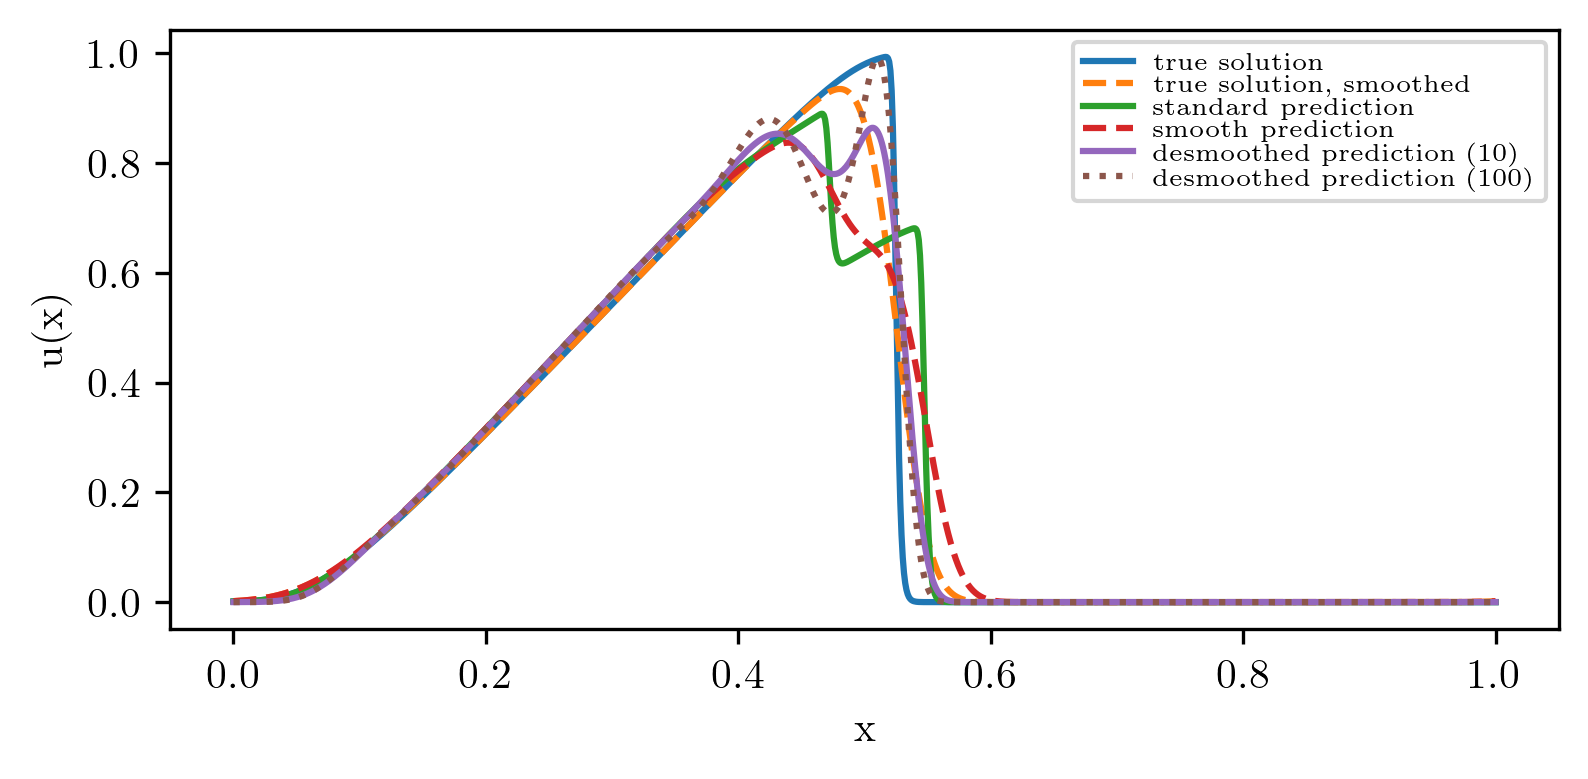

[0.02  0.024 0.028 0.032 0.036 0.04  0.036 0.032 0.028 0.024 0.02  0.024
 0.028 0.032 0.036 0.04  0.036 0.032 0.028 0.024 0.02  0.024 0.028 0.032
 0.036 0.04  0.036 0.032 0.028 0.024 0.02  0.024 0.028 0.032 0.036 0.04
 0.036 0.032 0.028 0.024 0.02  0.024 0.028 0.032 0.036 0.04  0.036 0.032
 0.028 0.024 0.02  0.024 0.028 0.032 0.036 0.04  0.036 0.032 0.028 0.024
 0.02  0.024 0.028 0.032 0.036 0.04  0.036 0.032 0.028 0.024 0.02  0.024
 0.028 0.032 0.036 0.04  0.036 0.032 0.028 0.024 0.02  0.024 0.028 0.032
 0.036 0.04  0.036 0.032 0.028 0.024 0.02  0.024 0.028 0.032 0.036 0.04
 0.036 0.032 0.028 0.024 0.02 ]
5
10
15
20
30
50
100


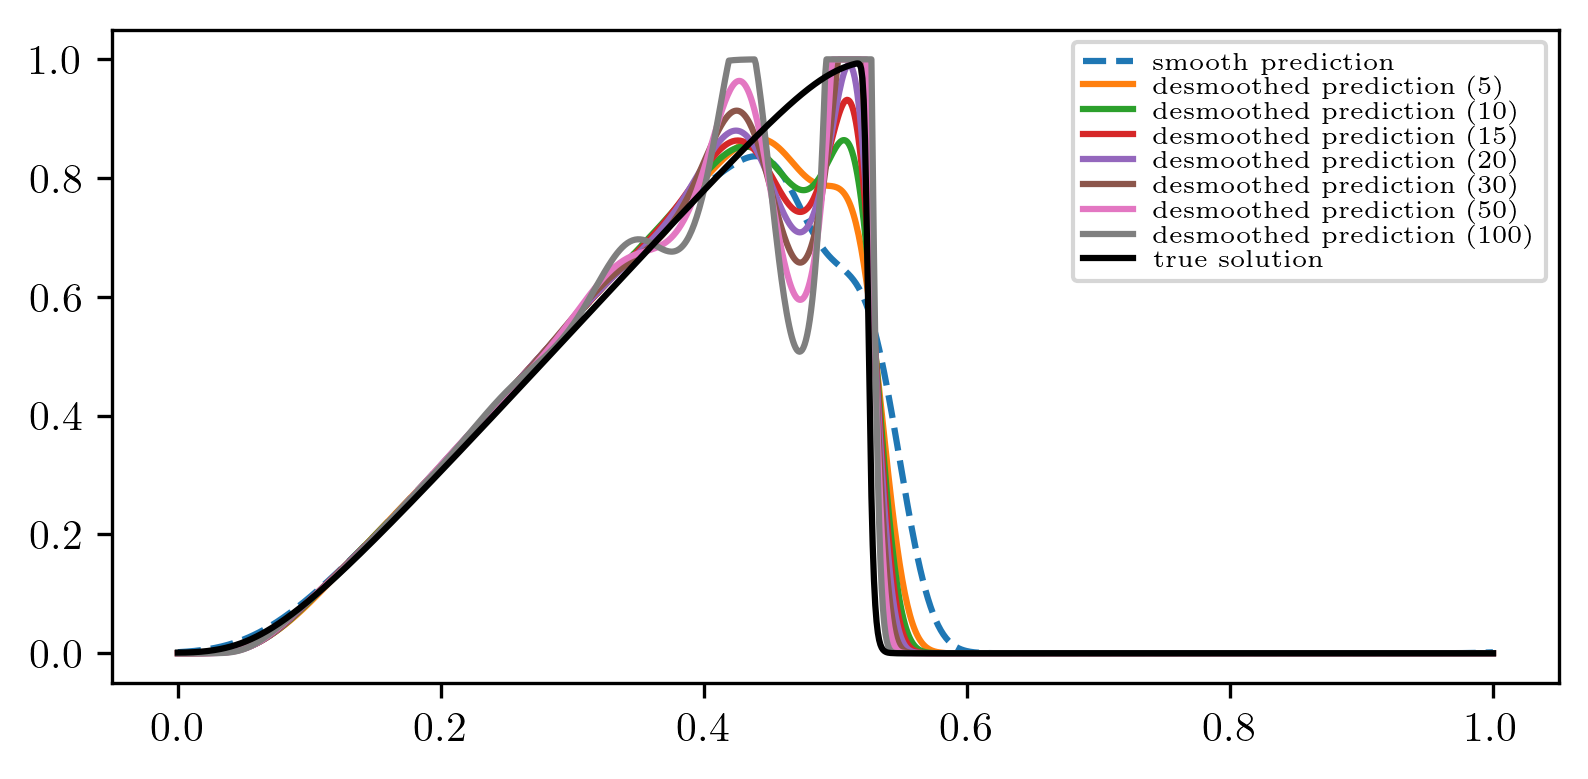

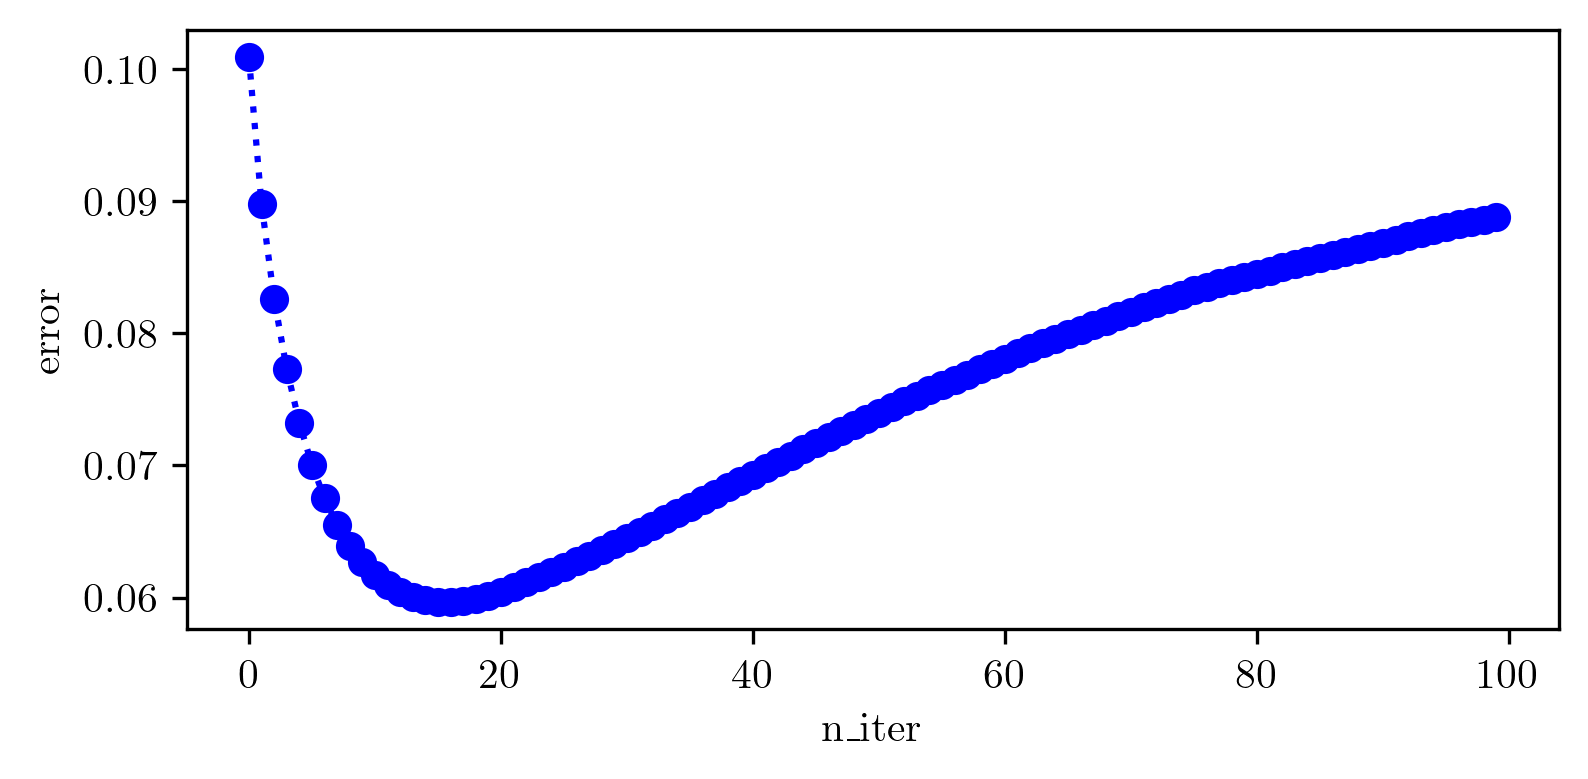

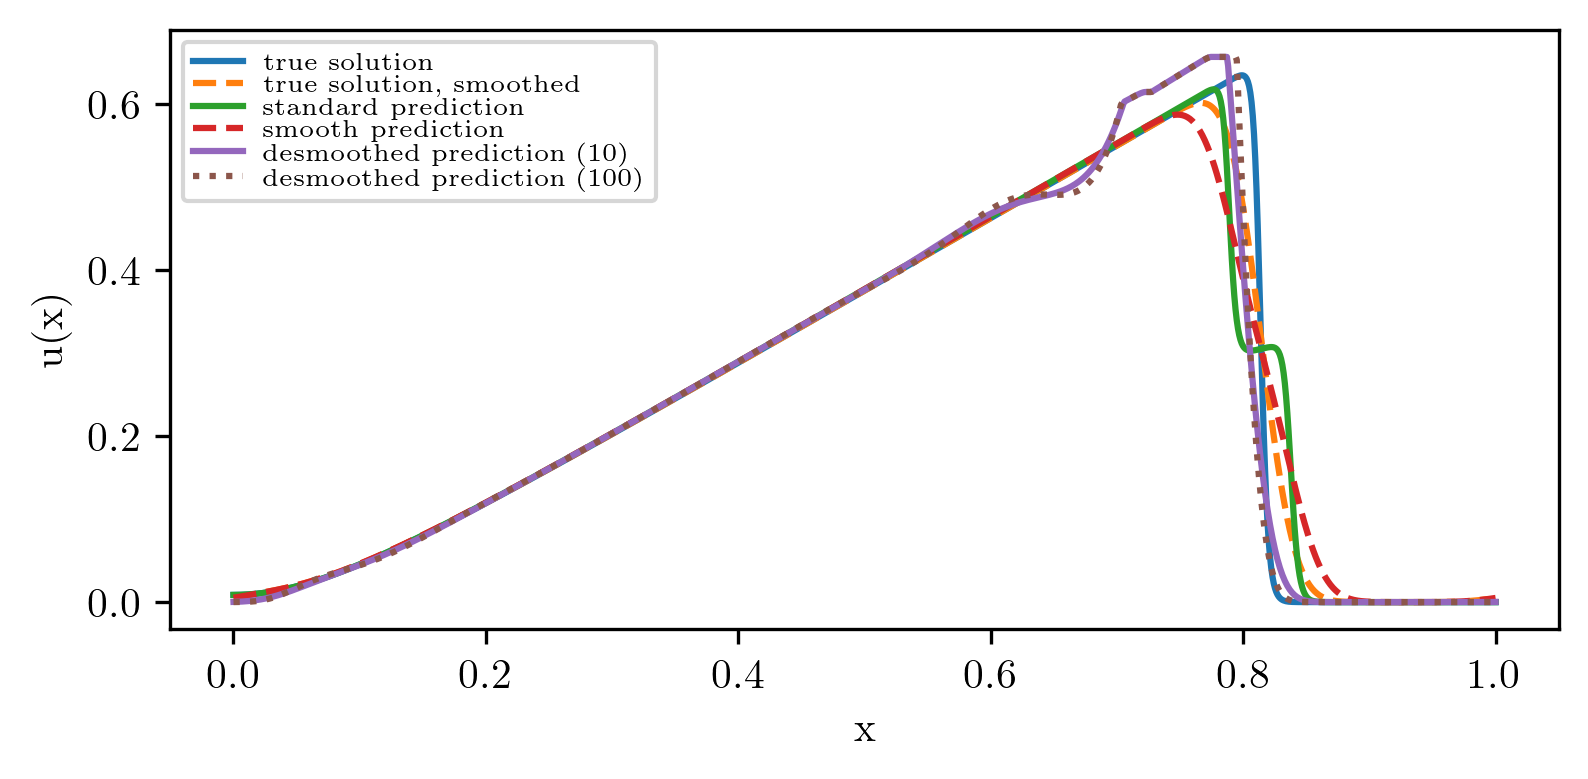

[0.02  0.024 0.028 0.032 0.036 0.04  0.036 0.032 0.028 0.024 0.02  0.024
 0.028 0.032 0.036 0.04  0.036 0.032 0.028 0.024 0.02  0.024 0.028 0.032
 0.036 0.04  0.036 0.032 0.028 0.024 0.02  0.024 0.028 0.032 0.036 0.04
 0.036 0.032 0.028 0.024 0.02  0.024 0.028 0.032 0.036 0.04  0.036 0.032
 0.028 0.024 0.02  0.024 0.028 0.032 0.036 0.04  0.036 0.032 0.028 0.024
 0.02  0.024 0.028 0.032 0.036 0.04  0.036 0.032 0.028 0.024 0.02  0.024
 0.028 0.032 0.036 0.04  0.036 0.032 0.028 0.024 0.02  0.024 0.028 0.032
 0.036 0.04  0.036 0.032 0.028 0.024 0.02  0.024 0.028 0.032 0.036 0.04
 0.036 0.032 0.028 0.024 0.02 ]
5
10
15
20
30
50
100


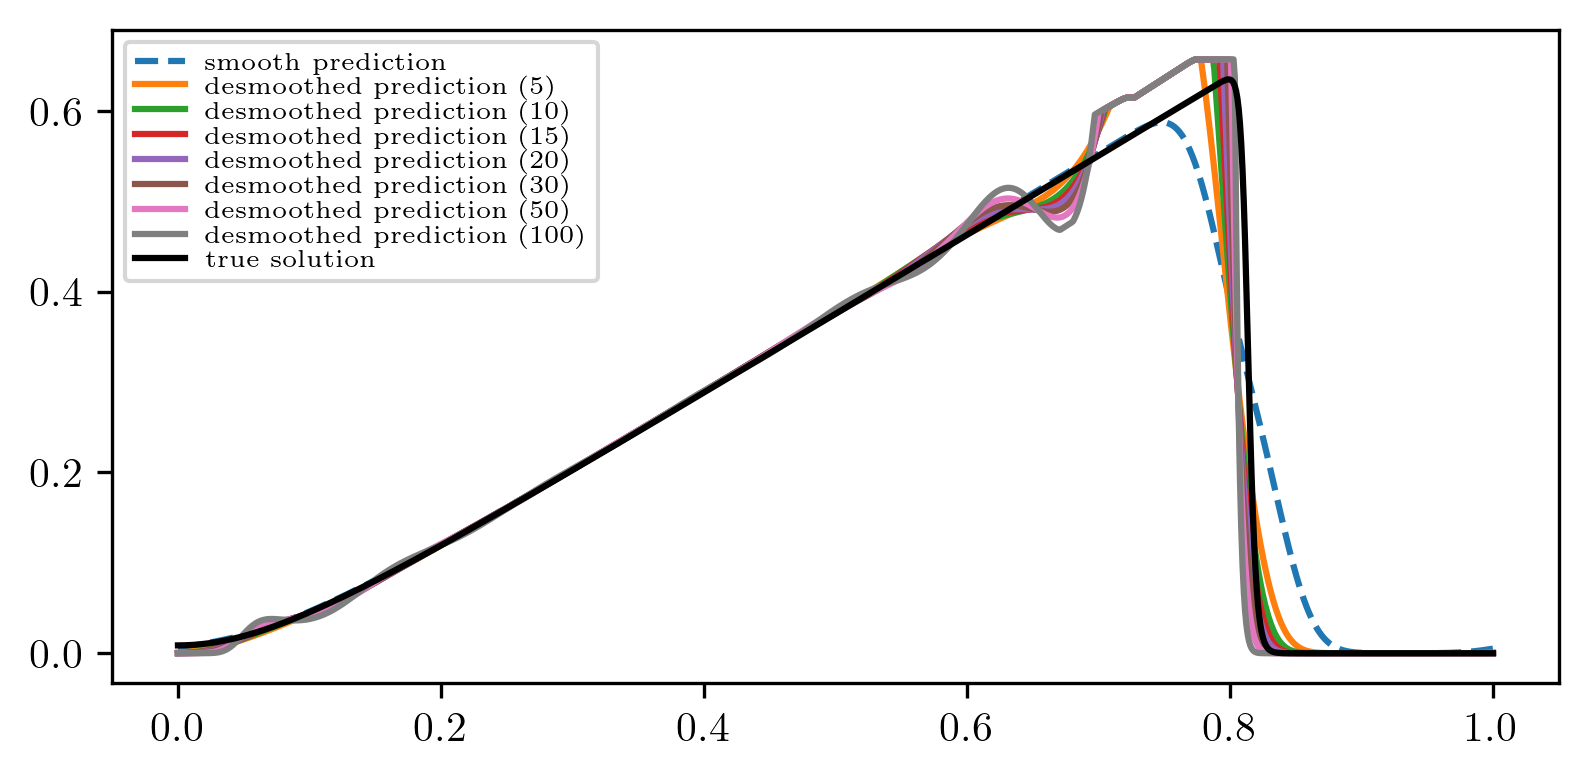

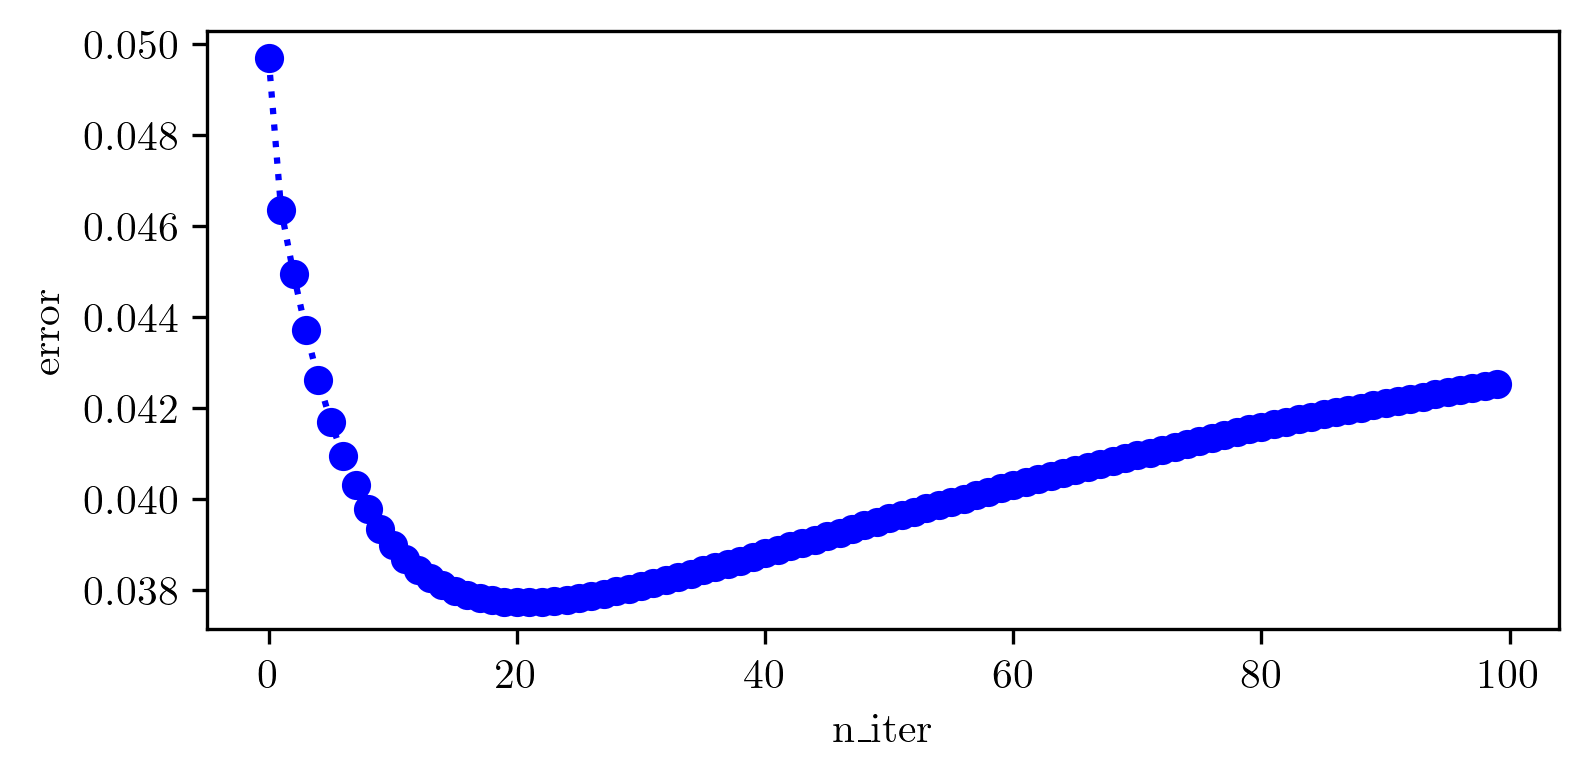

In [44]:
minvals, maxvals, distances = get_bounds(mu_train, mu_test, X_train)
sgm_est = sigma*(1 + c * distances)

for j in [20, 27, 75]:
    num_iter = 1

    plt.figure(figsize=(page_width_in, page_width_in/2))
    plt.plot(x, X_test[:, j], label="true solution")
    plt.plot(x, X_test_s[:, j], label="true solution, smoothed", ls="--")
    plt.plot(x, X_test_ROM[:, j], label="standard prediction")
    plt.plot(x, X_test_sROM[:, j], label="smooth prediction", ls="--")
    plt.plot(x, X_test_sROMs[:, j], label="desmoothed prediction (10)")
    plt.plot(x, X_test_sROMs2[:, j], label="desmoothed prediction (100)", ls=":")
    plt.legend()
    plt.xlabel("x")
    plt.ylabel("u(x)")
    plt.show()


    plt.figure(figsize=(page_width_in, page_width_in/2))
    plt.plot(x, X_test_sROM[:, j], label="smooth prediction", ls="--")
#     sgm_est = get_sigma(sigma, mu_test[j][None, ...], mu_train, c=c)
    print(sgm_est)
    for n_i in [5, 10, 15, 20, 30, 50, 100]:
        print(n_i)
        res = richardson_lucy(x, X_test_sROM[:, j].reshape(shape),
                                            sgm_est[j], n_i, truth=None,
                                            vmin=minvals[:, j], vmax=maxvals[:, j]).ravel()
        plt.plot(x, res, label="desmoothed prediction ({:.0f})".format(n_i))
    plt.plot(x, X_test[:, j], "k-", label="true solution")
    plt.legend()
    plt.show()
    e = np.empty(100,)
    for n_i, k in enumerate(np.arange(100)):
        res = richardson_lucy(x, X_test_sROM[:, j].reshape(shape),
                                            sgm_est[j], n_i, truth=None,
                                            vmin=minvals[:, j], vmax=maxvals[:, j]).ravel()
        e[k] = np.mean((res-X_test[:, j])**2)**.5
    plt.figure(figsize=(page_width_in, page_width_in/2))
    plt.plot(np.arange(100), e, "bo:")
    plt.xlabel("n_iter")
    plt.ylabel("error")
    plt.show()

Parameter Optimization

In [21]:
n_test = len(mu_test)

sgms = np.linspace(0, 0.05, 11)
c_all = np.linspace(0, 8, 17)
eROM = L2_error(X_test_ROM, X_test)
esROM_mat = np.zeros((n_test, len(sgms)))
esROMs_mat = np.zeros((n_test, len(sgms), len(c_all)))
esROMs2_mat = np.zeros((n_test, len(sgms), len(c_all)))
for i, sigma_s in enumerate(sgms):
    print(sigma_s)
    X_train_s = smoothen(X_train, sigma_s/dx, shape)
    smooth_rom = train_ROM(mu_train, X_train_s, rank=rank)
    X_test_sROM = smooth_rom.predict(mu_test).T
    esROM_mat[:, i] = L2_error(X_test_sROM, X_test)
    for j, c in enumerate(c_all):
        # de smoothing
        X_test_sROMs = post_process(x, X_test_sROM, sigma_s, c, mu_test, mu_train,
                                    num_iter1, shape=shape, X_train=X_train)
        esROMs_mat[:, i, j] = L2_error(X_test_sROMs, X_test)
        # de smoothing with a higher number of iterations
        X_test_sROMs2 = post_process(x, X_test_sROM, sigma_s, c, mu_test, mu_train,
                                    num_iter2, shape=shape, X_train=X_train)
        esROMs2_mat[:, i, j] = L2_error(X_test_sROMs2, X_test)

0.0


C:\Users\florianma\AppData\Local\Temp\ipykernel_39768\3100943040.py:4: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


0.005
0.01
0.015
0.02
0.025
0.03
0.035
0.04
0.045
0.05


-32.14401800920447 %


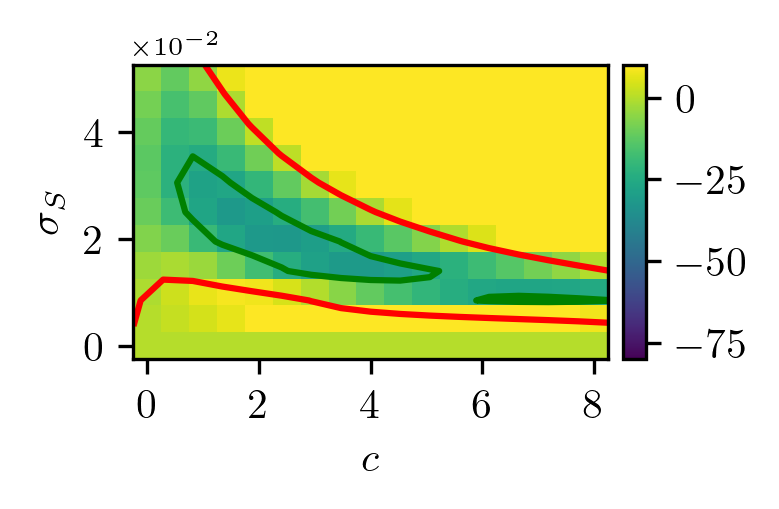

0.06368596992181377
0.05619045090691864
4 5 0.02 2.5


In [22]:
sigmas = sgms
mean_eROM = np.mean(eROM)
mean_esROM = np.mean(esROM_mat, axis=0)
mean_esROMs = np.mean(esROMs2_mat, axis=0)

# print(mean_eROM)
# print(np.min(mean_esROM), np.max(mean_esROM))
# print(np.min(mean_esROMs), np.max(mean_esROMs))
# print(np.min(mean_esROMs)/mean_eROM)
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
dc = c_all[1]-c_all[0]
ds = sigmas[1]-sigmas[0]
ext = (c_all[0]-dc/2, c_all[-1]+dc/2, (sigmas[0]-ds/2), (sigmas[-1]+ds/2))
Z = mean_esROMs/mean_eROM*100-100
print(np.min(Z), "%")
cs = ax.imshow(Z, interpolation="nearest", origin="lower", vmin=-80, vmax=10, extent=ext)
contours = ax.contour(Z, levels=[-75, -50, -25, 0], colors=["g", "g", "g", "r"], extent=ext)
#     cs.cmap.set_over('red')
#     cs.cmap.set_under('blue')
#np.save(pth+"mean_esROMs.npy", mean_esROMs)
ax.set_xticks(c_all[::4])
ax.set_yticks(sigmas[::4])
ax.set_xlabel("$c$")
ax.set_ylabel("$\sigma_S$")
ax.set_aspect("auto")
#     ax.ticklabel_format(axis='y', style='sci', useOffset=True)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0), useOffset=False, useMathText=True)
ax.yaxis.get_offset_text().set_size(6)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(cs, cax=cax)
cbar.set_ticks([-75, -50, -25, 0])
plt.savefig(pth+"2nd_ex_hyperparams.pdf")
plt.show()
print(np.min(mean_esROMs[0, :]))
print(np.min(mean_esROMs[-1, :]))
i, j = np.unravel_index(np.argmin(mean_esROMs, axis=None), mean_esROMs.shape)
print(i, j, sigmas[i], c_all[j])
sigma, c = sigmas[i], c_all[j]

-29.63648158653784 %


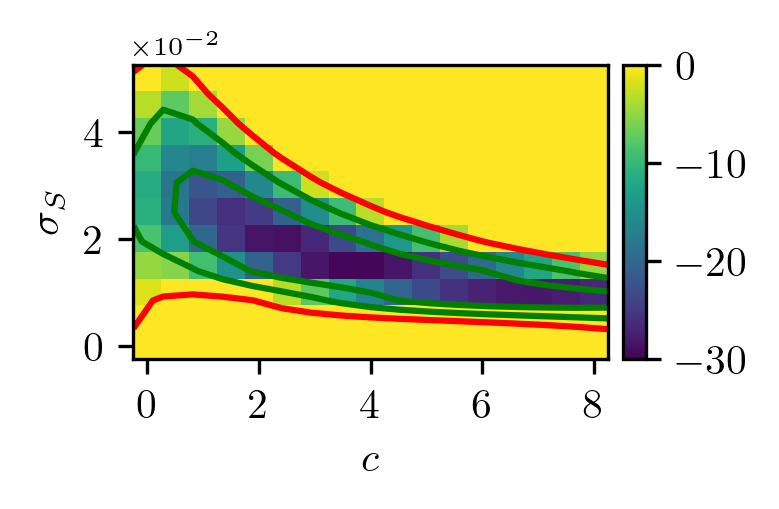

0.06368596992181363
0.062231980600384956
3 7 0.015 3.5


In [23]:
sigmas = sgms
mean_eROM = np.mean(eROM)
mean_esROM = np.mean(esROM_mat, axis=0)
mean_esROMs = np.mean(esROMs_mat, axis=0)

# print(mean_eROM)
# print(np.min(mean_esROM), np.max(mean_esROM))
# print(np.min(mean_esROMs), np.max(mean_esROMs))
# print(np.min(mean_esROMs)/mean_eROM)
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
dc = c_all[1]-c_all[0]
ds = sigmas[1]-sigmas[0]
ext = (c_all[0]-dc/2, c_all[-1]+dc/2, (sigmas[0]-ds/2), (sigmas[-1]+ds/2))
Z = mean_esROMs/mean_eROM*100-100
print(np.min(Z), "%")
cs = ax.imshow(Z, interpolation="nearest", origin="lower", vmin=-30, vmax=0, extent=ext)
contours = ax.contour(Z, levels=[-30, -20, -10, 0], colors=["g", "g", "g", "r"], extent=ext)
#     cs.cmap.set_over('red')
#     cs.cmap.set_under('blue')
#np.save(pth+"mean_esROMs.npy", mean_esROMs)
ax.set_xticks(c_all[::4])
ax.set_yticks(sigmas[::4])
ax.set_xlabel("$c$")
ax.set_ylabel("$\sigma_S$")
ax.set_aspect("auto")
#     ax.ticklabel_format(axis='y', style='sci', useOffset=True)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0), useOffset=False, useMathText=True)
ax.yaxis.get_offset_text().set_size(6)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(cs, cax=cax)
cbar.set_ticks([-30, -20, -10, 0])
plt.savefig(pth+"2nd_ex_hyperparams1D.pdf")
plt.show()
print(np.min(mean_esROMs[0, :]))
print(np.min(mean_esROMs[-1, :]))
i, j = np.unravel_index(np.argmin(mean_esROMs, axis=None), mean_esROMs.shape)
print(i, j, sigmas[i], c_all[j])
sigma, c = sigmas[i], c_all[j]

error over time (different models)